In [ ]:
from pyspark.sql import SparkSession

# Créer la SparkSession
spark = SparkSession.builder     .appName("ProjetBigData - MovieLens")     .getOrCreate()

In [ ]:
# Lire les fichiers CSV depuis HDFS
ratings_df = spark.read.csv("hdfs://namenode:9000/datasets/rating.csv", header=True, inferSchema=True)
movies_df = spark.read.csv("hdfs://namenode:9000/datasets/movie.csv", header=True, inferSchema=True)

# Afficher les premières lignes
ratings_df.show(5)
movies_df.show(5)

In [ ]:
# Installer les packages manquants directement depuis Jupyter
!pip install --no-cache-dir pandas matplotlib seaborn numpy


In [ ]:
!pip install pyspark

In [ ]:
from pyspark.sql import SparkSession
from pyspark.sql import functions as F
from pyspark.ml.recommendation import ALS
from pyspark.ml.evaluation import RegressionEvaluator
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
spark = SparkSession.builder.appName("MovieLens").getOrCreate()

In [ ]:
ratings_df.printSchema()
movies_df.printSchema()
ratings_df.show(5)
movies_df.show(5)

root
 |-- userId: integer (nullable = true)
 |-- movieId: integer (nullable = true)
 |-- rating: double (nullable = true)
 |-- timestamp: timestamp (nullable = true)

root
 |-- movieId: integer (nullable = true)
 |-- title: string (nullable = true)
 |-- genres: string (nullable = true)

+------+-------+------+-------------------+
|userId|movieId|rating|          timestamp|
+------+-------+------+-------------------+
|     1|      2|   3.5|2005-04-02 23:53:47|
|     1|     29|   3.5|2005-04-02 23:31:16|
|     1|     32|   3.5|2005-04-02 23:33:39|
|     1|     47|   3.5|2005-04-02 23:32:07|
|     1|     50|   3.5|2005-04-02 23:29:40|
+------+-------+------+-------------------+
only showing top 5 rows

+-------+--------------------+--------------------+
|movieId|               title|              genres|
+-------+--------------------+--------------------+
|      1|    Toy Story (1995)|Adventure|Animati...|
|      2|      Jumanji (1995)|Adventure|Childre...|
|      3|Grumpier Old Men ...| 

In [ ]:
ratings_df.describe().show()
print("Nombre d'utilisateurs :", ratings_df.select("userId").distinct().count())
print("Nombre de films :", ratings_df.select("movieId").distinct().count())
print("Nombre total de notes :", ratings_df.count())

+-------+-----------------+------------------+------------------+
|summary|           userId|           movieId|            rating|
+-------+-----------------+------------------+------------------+
|  count|         20000263|          20000263|          20000263|
|   mean|69045.87258292554| 9041.567330339605|3.5255285642993797|
| stddev|40038.62665316267|19789.477445413264| 1.051988919294229|
|    min|                1|                 1|               0.5|
|    max|           138493|            131262|               5.0|
+-------+-----------------+------------------+------------------+

Nombre d'utilisateurs : 138493
Nombre de films : 26744
Nombre total de notes : 20000263


In [ ]:
for col in ratings_df.columns:
    print(f"{col} : {ratings_df.filter(F.col(col).isNull()).count()} valeurs manquantes")
for col in movies_df.columns:
    print(f"{col} : {movies_df.filter(F.col(col).isNull()).count()} valeurs manquantes")

print("Doublons ratings :", ratings_df.count() - ratings_df.dropDuplicates().count())
print("Doublons movies :", movies_df.count() - movies_df.dropDuplicates().count())

userId : 0 valeurs manquantes
movieId : 0 valeurs manquantes
rating : 0 valeurs manquantes
timestamp : 0 valeurs manquantes
movieId : 0 valeurs manquantes
title : 0 valeurs manquantes
genres : 0 valeurs manquantes
Doublons ratings : 0
Doublons movies : 0


In [ ]:
# Suppression des doublons
ratings_df = ratings_df.dropDuplicates()
movies_df = movies_df.dropDuplicates()

# Suppression des valeurs manquantes
ratings_df = ratings_df.dropna()
movies_df = movies_df.dropna()

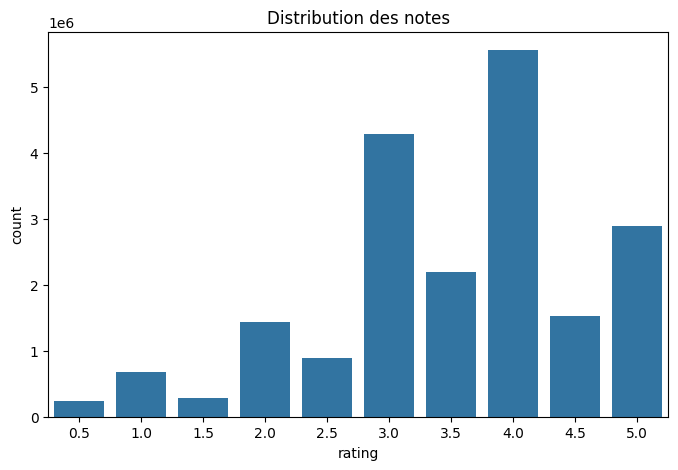

In [ ]:
ratings_dist = ratings_df.groupBy("rating").count().orderBy("rating")
ratings_pd = ratings_dist.toPandas()
plt.figure(figsize=(8,5))
sns.barplot(x="rating", y="count", data=ratings_pd)
plt.title("Distribution des notes")
plt.show()

In [ ]:
top_movies = ratings_df.groupBy("movieId").count().orderBy(F.desc("count")).limit(10)
top_movies = top_movies.join(movies_df, "movieId")
top_movies.select("title", "count").show(truncate=False)

+-----------------------------------------+-----+
|title                                    |count|
+-----------------------------------------+-----+
|Pulp Fiction (1994)                      |67310|
|Jurassic Park (1993)                     |59715|
|Forrest Gump (1994)                      |66172|
|Shawshank Redemption, The (1994)         |63366|
|Silence of the Lambs, The (1991)         |63299|
|Braveheart (1995)                        |53769|
|Star Wars: Episode IV - A New Hope (1977)|54502|
|Terminator 2: Judgment Day (1991)        |52244|
|Matrix, The (1999)                       |51334|
|Schindler's List (1993)                  |50054|
+-----------------------------------------+-----+



In [ ]:
ratings_df = ratings_df.withColumn("userId", F.col("userId").cast("int"))
ratings_df = ratings_df.withColumn("movieId", F.col("movieId").cast("int"))
ratings_df = ratings_df.withColumn("rating", F.col("rating").cast("float"))

In [ ]:
ratings_small = ratings_df.sample(fraction=0.1, seed=42)


In [ ]:
(training, test) = ratings_small.randomSplit([0.8, 0.2], seed=42)

In [ ]:
als = ALS(
    maxIter=10,
    regParam=0.1,
    userCol="userId",
    itemCol="movieId",
    ratingCol="rating",
    coldStartStrategy="drop"
)
model = als.fit(training)

In [ ]:
test_sample = test.sample(fraction=0.1, seed=42)
predictions = model.transform(test_sample)
evaluator = RegressionEvaluator(
    metricName="rmse",
    labelCol="rating",
    predictionCol="prediction"
)
rmse = evaluator.evaluate(predictions)
print(f"RMSE du modèle : {rmse:.4f}")

RMSE du modèle : 0.8087


In [ ]:
userRecs = model.recommendForAllUsers(5)
userRecs.show(5, truncate=False)

+------+------------------------------------------------------------------------------------------------------+
|userId|recommendations                                                                                       |
+------+------------------------------------------------------------------------------------------------------+
|1     |[{128812, 5.7489696}, {121029, 5.602302}, {129536, 5.389169}, {95776, 5.3552904}, {117907, 5.2768836}]|
|3     |[{128812, 6.961052}, {129536, 6.202922}, {121029, 6.1254497}, {95776, 5.904415}, {117907, 5.8896785}] |
|5     |[{128812, 6.7500143}, {121029, 6.4601197}, {77736, 5.9846864}, {129536, 5.754955}, {86237, 5.7062063}]|
|6     |[{126219, 6.1322494}, {3226, 5.4623504}, {77736, 5.260418}, {121029, 5.2227826}, {69609, 5.166953}]   |
|9     |[{128812, 5.207819}, {27092, 5.061773}, {129536, 5.056454}, {121029, 5.041155}, {128981, 4.8850193}]  |
+------+------------------------------------------------------------------------------------------------

In [ ]:
user_id = 1
user_subset = ratings_df.select("userId").where(F.col("userId") == user_id).distinct()
recs = model.recommendForUserSubset(user_subset, 5)
recs.show(truncate=False)

+------+------------------------------------------------------------------------------------------------------+
|userId|recommendations                                                                                       |
+------+------------------------------------------------------------------------------------------------------+
|1     |[{128812, 5.7489696}, {121029, 5.602302}, {129536, 5.389169}, {95776, 5.3552904}, {117907, 5.2768836}]|
+------+------------------------------------------------------------------------------------------------------+



In [ ]:
from pyspark.sql.functions import explode

recs_exploded = recs.withColumn("rec", explode("recommendations")) \
    .select("userId", F.col("rec.movieId"), F.col("rec.rating"))
recs_with_titles = recs_exploded.join(movies_df, "movieId")
recs_with_titles.select("userId", "title", "rating").show(truncate=False)

+------+--------------------------------------+---------+
|userId|title                                 |rating   |
+------+--------------------------------------+---------+
|1     |Drew: The Man Behind the Poster (2013)|5.7489696|
|1     |No Distance Left to Run (2010)        |5.602302 |
|1     |Code Name Coq Rouge (1989)            |5.389169 |
|1     |Bob Funk (2009)                       |5.3552904|
|1     |My Brother Tom (2001)                 |5.2768836|
+------+--------------------------------------+---------+



In [ ]:
# On suppose que recs_with_titles est déjà créé comme dans l’étape 9.3
recs_pd = recs_with_titles.toPandas()

In [ ]:
import pandas as pd
from IPython.display import display

display(recs_pd)

,movieId,userId,rating,title,genres
0,128812,1,5.748970,Drew: The Man Behind the Poster (2013),Documentary
1,121029,1,5.602302,No Distance Left to Run (2010),Documentary
2,129536,1,5.389169,Code Name Coq Rouge (1989),(no genres listed)
3,95776,1,5.355290,Bob Funk (2009),Comedy|Romance
4,117907,1,5.276884,My Brother Tom (2001),Drama


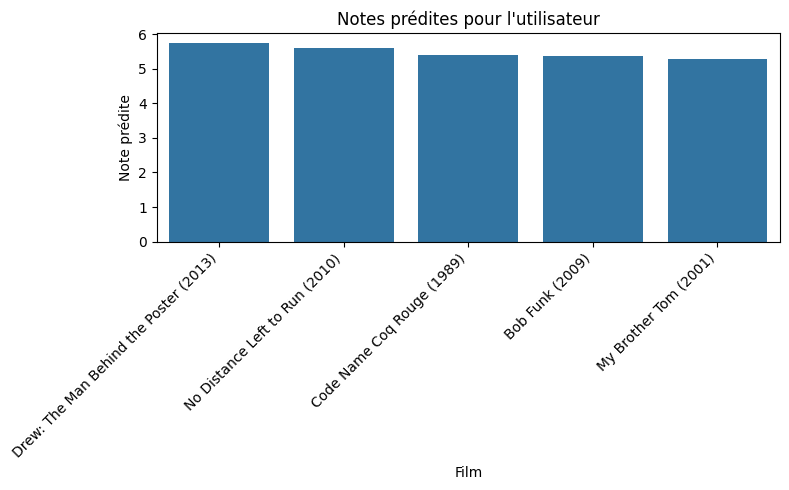

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,5))
sns.barplot(x="title", y="rating", data=recs_pd)
plt.title("Notes prédites pour l'utilisateur")
plt.xticks(rotation=45, ha='right')
plt.ylabel("Note prédite")
plt.xlabel("Film")
plt.tight_layout()
plt.show()

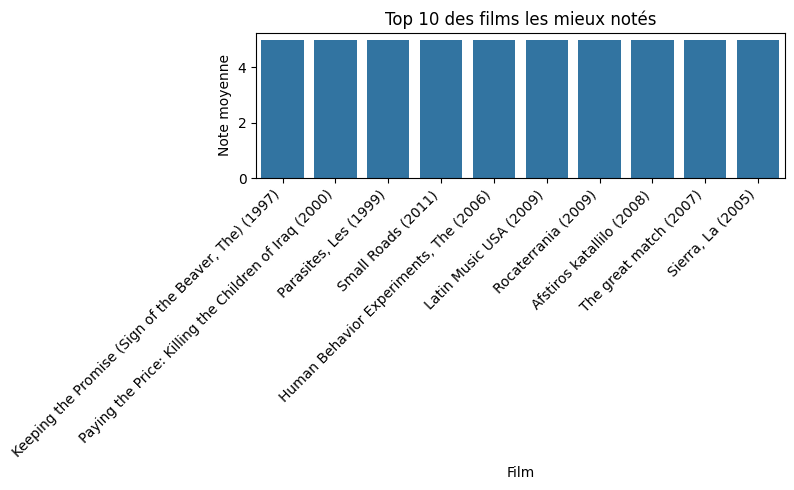

In [ ]:
top_movies = ratings_df.groupBy("movieId").agg(F.count("rating").alias("nb_ratings"), F.avg("rating").alias("avg_rating"))
top_movies = top_movies.join(movies_df, "movieId").orderBy(F.desc("avg_rating"))
top_movies_pd = top_movies.toPandas().sort_values(by="avg_rating", ascending=False).head(10)

plt.figure(figsize=(8,5))
sns.barplot(x="title", y="avg_rating", data=top_movies_pd)
plt.title("Top 10 des films les mieux notés")
plt.xticks(rotation=45, ha='right')
plt.ylabel("Note moyenne")
plt.xlabel("Film")
plt.tight_layout()
plt.show()